In [13]:
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [14]:
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-flash-lite-latest")

In [15]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [16]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [17]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state['joke']}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

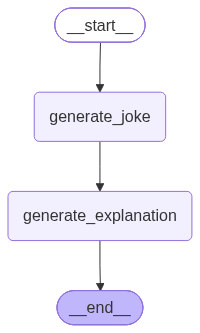

In [18]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [19]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'My wife told me to stop impersonating a flamingo. \n\nI had to put my foot down. \n\n...Which is also what I do when the delivery guy forgets to slice my pizza, because frankly, it’s easier to just eat the whole thing at once.',
   'extras': {'signature': 'El4KXAERTTIP86OshGu0x0qtbI9qUIgJ8pEy2zB/HV15q7O85DPKTskpxU1yzfYAYhWMFGz8poONkZMYyaPDTVdaZhhYzWlSXKr+CwjdUOkyAVLhz5u5LEJe6J6SNyG7'}}],
 'explanation': [{'type': 'text',
   'text': 'Here is an explanation of the joke, which is actually a combination of a classic pun and an unexpected punchline:\n\n1. **The Setup:** *“My wife told me to stop impersonating a flamingo.”* \n   Flamingos are famously known for standing on one leg. \n\n2. **The First Punchline (The Pun):** *“I had to put my foot down.”* \n   The phrase "to put your foot down" is an idiom that means to take a firm stand or assert your authority. However, taken literally in the context of a flamingo, it means to lower y

In [20]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'My wife told me to stop impersonating a flamingo. \n\nI had to put my foot down. \n\n...Which is also what I do when the delivery guy forgets to slice my pizza, because frankly, it’s easier to just eat the whole thing at once.', 'extras': {'signature': 'El4KXAERTTIP86OshGu0x0qtbI9qUIgJ8pEy2zB/HV15q7O85DPKTskpxU1yzfYAYhWMFGz8poONkZMYyaPDTVdaZhhYzWlSXKr+CwjdUOkyAVLhz5u5LEJe6J6SNyG7'}}], 'explanation': [{'type': 'text', 'text': 'Here is an explanation of the joke, which is actually a combination of a classic pun and an unexpected punchline:\n\n1. **The Setup:** *“My wife told me to stop impersonating a flamingo.”* \n   Flamingos are famously known for standing on one leg. \n\n2. **The First Punchline (The Pun):** *“I had to put my foot down.”* \n   The phrase "to put your foot down" is an idiom that means to take a firm stand or assert your authority. However, taken literally in the context of a flamingo, it means 

In [21]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'My wife told me to stop impersonating a flamingo. \n\nI had to put my foot down. \n\n...Which is also what I do when the delivery guy forgets to slice my pizza, because frankly, it’s easier to just eat the whole thing at once.', 'extras': {'signature': 'El4KXAERTTIP86OshGu0x0qtbI9qUIgJ8pEy2zB/HV15q7O85DPKTskpxU1yzfYAYhWMFGz8poONkZMYyaPDTVdaZhhYzWlSXKr+CwjdUOkyAVLhz5u5LEJe6J6SNyG7'}}], 'explanation': [{'type': 'text', 'text': 'Here is an explanation of the joke, which is actually a combination of a classic pun and an unexpected punchline:\n\n1. **The Setup:** *“My wife told me to stop impersonating a flamingo.”* \n   Flamingos are famously known for standing on one leg. \n\n2. **The First Punchline (The Pun):** *“I had to put my foot down.”* \n   The phrase "to put your foot down" is an idiom that means to take a firm stand or assert your authority. However, taken literally in the context of a flamingo, it means

In [22]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': [{'type': 'text',
   'text': "Why do pasta chefs live such dangerous lives?\n\nBecause they're always living on the *penne* edge!",
   'extras': {'signature': 'El4KXAERTTIPgPGntNwf3RoarNRvJ4DGoqWgKSoZZ9Pq6cZ282j7lG0ePohUtnzRveJWHrhHZv2T3l239Xe8BAq6pEqMnlHF+vup/ikrCVYSDDcA59RYrwFw4RTm1E2/'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is a pun based on a play on words:\n\n1. **"Penne"** is a type of tube-shaped pasta. It is pronounced like the word "penny."\n2. **"Living on the edge"** is a common idiom that means taking risks, living dangerously, or being in a thrilling situation. \n\nBy replacing the word "penny" (as in "living on a penny/edge") or combining "penne" with the phrase, the joke creates a humorous double meaning about Italian chefs who make pasta taking extreme risks.',
   'extras': {'signature': 'El4KXAERTTIPfres4ntVVxKU1ku27JS/xGd3eFIA7NwR1fSOluX7AeSPbF6y31WgEa2grdoyMoDIxGybE8/yHNPpXR9QKKn9+CafC6zzwrIal2h+UGmk4YOneSqJM+RH'}}]}

In [23]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'My wife told me to stop impersonating a flamingo. \n\nI had to put my foot down. \n\n...Which is also what I do when the delivery guy forgets to slice my pizza, because frankly, it’s easier to just eat the whole thing at once.', 'extras': {'signature': 'El4KXAERTTIP86OshGu0x0qtbI9qUIgJ8pEy2zB/HV15q7O85DPKTskpxU1yzfYAYhWMFGz8poONkZMYyaPDTVdaZhhYzWlSXKr+CwjdUOkyAVLhz5u5LEJe6J6SNyG7'}}], 'explanation': [{'type': 'text', 'text': 'Here is an explanation of the joke, which is actually a combination of a classic pun and an unexpected punchline:\n\n1. **The Setup:** *“My wife told me to stop impersonating a flamingo.”* \n   Flamingos are famously known for standing on one leg. \n\n2. **The First Punchline (The Pun):** *“I had to put my foot down.”* \n   The phrase "to put your foot down" is an idiom that means to take a firm stand or assert your authority. However, taken literally in the context of a flamingo, it means

Time Travel

In [24]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1ab455-d9c1-658f-8000-532684e51189"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1ab455-d9c1-658f-8000-532684e51189'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-08T05:23:03.679921+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ab455-d9ac-6664-bfff-83900cf49650'}}, tasks=(PregelTask(id='69824dde-87c0-f3ac-582e-5986b59ee339', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': [{'type': 'text', 'text': 'My wife told me to stop impersonating a flamingo. \n\nI had to put my foot down. \n\n...Which is also what I do when the delivery guy forgets to slice my pizza, because frankly, it’s easier to just eat the whole thing at once.', 'extras': {'signature': 'El4KXAERTTIP86OshGu0x0qtbI9qUIgJ8pEy2zB/HV15q7O85DPKTskpxU1yzfYAYhWMFGz8poONkZMYyaPDTVdaZhhYzWlSXKr+CwjdUOkyAVLhz5u5LEJe6J6SNyG7'}}]}),), in

In [25]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1ab455-d9c1-658f-8000-532684e51189"}})

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'Why do pizza makers go to heaven?\n\nBecause they know how to *heav-en-ly* slice, but seriously—because they always deliver!',
   'extras': {'signature': 'El4KXAERTTIP10ciom1/3L17+/vmNUcKE1oi2Xh+njDD1aRVd6EfOnZHi0ro5fgHfxCj7ZeKVi+2V+Et6RID46CJzil4wg5z+2t/IXR0QZRy2UaUuWnCjlfBFV9U/wl4'}}],
 'explanation': [{'type': 'text',
   'text': 'Here is an explanation of the joke:\n\n**The Joke:**\n> *“Why do pizza makers go to heaven?*\n> *Because they know how to heav-en-ly slice, but seriously—because they always deliver!”*\n\n---\n\n### **Explanation:**\n\nThis joke relies on a **double entendre** (a phrase with two meanings) and a classic comedic "bait-and-switch" structure:\n\n1. **The Setup:** It asks a traditional riddle format: *"Why do pizza makers go to heaven?"*\n2. **The Fake-Out (Puntastic wordplay):** The first part of the answer suggests they go to heaven because they make *“heav-en-ly slice[s]”* (playing on the word "heaven"

In [26]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why do pizza makers go to heaven?\n\nBecause they know how to *heav-en-ly* slice, but seriously—because they always deliver!', 'extras': {'signature': 'El4KXAERTTIP10ciom1/3L17+/vmNUcKE1oi2Xh+njDD1aRVd6EfOnZHi0ro5fgHfxCj7ZeKVi+2V+Et6RID46CJzil4wg5z+2t/IXR0QZRy2UaUuWnCjlfBFV9U/wl4'}}], 'explanation': [{'type': 'text', 'text': 'Here is an explanation of the joke:\n\n**The Joke:**\n> *“Why do pizza makers go to heaven?*\n> *Because they know how to heav-en-ly slice, but seriously—because they always deliver!”*\n\n---\n\n### **Explanation:**\n\nThis joke relies on a **double entendre** (a phrase with two meanings) and a classic comedic "bait-and-switch" structure:\n\n1. **The Setup:** It asks a traditional riddle format: *"Why do pizza makers go to heaven?"*\n2. **The Fake-Out (Puntastic wordplay):** The first part of the answer suggests they go to heaven because they make *“heav-en-ly slice[s]”* (playing on the wo

Updating State

In [29]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1ab455-d9c1-658f-8000-532684e51189", "checkpoint_ns": ""}}, {"topic": "samosa"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1ab469-ee1d-640c-8001-cd622315ba9c'}}

In [30]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ab469-ee1d-640c-8001-cd622315ba9c'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-09-08T05:32:02.685609+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1ab455-d9c1-658f-8000-532684e51189'}}, tasks=(PregelTask(id='ec243daa-f51d-af21-233e-f1ca29db957b', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why do pizza makers go to heaven?\n\nBecause they know how to *heav-en-ly* slice, but seriously—because they always deliver!', 'extras': {'signature': 'El4KXAERTTIP10ciom1/3L17+/vmNUcKE1oi2Xh+njDD1aRVd6EfOnZHi0ro5fgHfxCj7ZeKVi+2V+Et6RID46CJzil4wg5z+2t/IXR0QZRy2UaUuWnCjlfBFV9U/wl4'}}], 'explanation': [{'

In [32]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1ab469-ee1d-640c-8001-cd622315ba9c"}})

{'topic': 'samosa',
 'joke': [{'type': 'text',
   'text': 'Why did the samosa go to therapy?\n\nBecause it felt like everyone was just trying to get inside its head, and its spicy personality was too much for the mainstream. \n\nBesides, it had too many layers of emotional baggage!',
   'extras': {'signature': 'El4KXAERTTIP1eonAsuWBKj0oCzQOhCcx7daLD56NHaElwuc5ytCrt99ZPbc/24unXhF3YAky1R9LHbQahftSGDIiuHTXaH9q2tcwiIfWQGRDlARetLyNC2dC0esIr1B'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is a play on words (a pun) that combines the physical characteristics of a samosa with common human emotional struggles dealt with in therapy. Here is the breakdown:\n\n1. **"Everyone was just trying to get inside its head":** \n   * *Literal meaning:* A samosa is a pastry stuffed with fillings (like potatoes, peas, or meat), so people literally have to "get inside" it to eat it.\n   * *Therapeutic meaning:* In human terms, feeling like people are "in your head" means feeling over-analyzed, o